In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from TDECalculator import TDECalculator

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [84]:
def plot_dens_time(calc, times):
    n = len(times)

    nbins = 300
    x_edges = np.linspace(-2, 2, nbins+1)
    y_edges = np.linspace(-3, 3, nbins+1)
    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]
    area = dx * dy

    # Precompute interpolated densities
    interp_densities = []
    for time in times:
        equator_sample = calc.equator_sample(idx_from_tde=time, n_phi=3000)
        POS = equator_sample['POS']
        dMass = equator_sample['dMass']

        x_pos = POS[..., 0].flatten()
        y_pos = POS[..., 1].flatten()
        mass_flat = dMass.flatten()

        mass_hist, _, _ = np.histogram2d(
            x_pos, y_pos,
            bins=[x_edges, y_edges],
            weights=mass_flat
        )
        density2D = mass_hist / area

        Xc, Yc = np.meshgrid(
            0.5 * (x_edges[:-1] + x_edges[1:]),
            0.5 * (y_edges[:-1] + y_edges[1:])
        )
        density2D += 1e-12 * (Xc + Yc)

        points = np.column_stack((Xc.flatten(), Yc.flatten()))
        values = density2D.T.flatten()
        xi = np.linspace(Xc.min(), Xc.max(), nbins-1)
        yi = np.linspace(Yc.min(), Yc.max(), nbins-1)
        XI, YI = np.meshgrid(xi, yi)
        dens_interp = griddata(points, values, (XI, YI), method='linear')

        dens_interp += dens_interp.max() * 1e-8
        dens_interp /= dens_interp.max()

        interp_densities.append((dens_interp, XI, YI, calc))

    # Shared log-scale limits
    global_min = min(d[d[0] > 0].min() for d, _, _, _ in interp_densities)
    global_max = 1.0  # normalized
    levels = np.logspace(np.log10(global_min), np.log10(global_max), 100)
    norm = LogNorm(vmin=global_min, vmax=global_max)

    # Setup figure with extra column on RIGHT for colorbar
    fig = plt.figure(figsize=(n * 6 + 2, 9.7))
    gs = GridSpec(1, n + 1, width_ratios=[1]*n + [0.06], wspace=0.03)

    # Plot subplots
    for idx, (dens_interp, XI, YI, calc) in enumerate(interp_densities):
        ax = fig.add_subplot(gs[0, idx])

        cf = ax.contourf(XI, YI, dens_interp, levels=levels, cmap='viridis', norm=norm)

        i_tde = np.argmin(np.abs(calc.t - calc.t_TDE)) + times[idx]

        phi = calc.Phi

        if isinstance(calc.Phi, interp1d):
            phi = calc.Phi(calc.t)
            
        phi0 = phi[i_tde]
        
        ax.arrow(-1.5, 2.25, -0.3*np.cos(phi0), -0.3*np.sin(phi0),
                 linewidth=2, head_width=0.1, head_length=0.1, color='white')
        ax.text(-1.5-0.3*np.cos(phi0)+0.1,
                2.25-0.3*np.sin(phi0)+0.1,
                'to BH', color='white', fontsize=18)

        beta = calc.Rtidal / calc.Rp
        name = calc.star_name[4:-4].replace('p', '.')
        ax.text(1.1, 2.5, fr'${name}\,M_\odot$',
                color='white', fontsize=28, fontweight='bold')
        ax.text(-1.7, -2.5, fr'$\beta={beta:.2f}$',
                color='white', fontsize=28, fontweight='bold')
        ax.text(0.2, -2.5, fr'$idx={times[idx]:.2f}$',
                color='white', fontsize=28, fontweight='bold')

        ax.set_aspect('equal')
        ax.axis('off')

    # Colorbar axis on far RIGHT
    cax = fig.add_subplot(gs[0, -1])
    cb = fig.colorbar(cf, cax=cax)
    cb.set_label('$\\rho/\\rho_c$')
    cb.set_ticks([1e-8, 1e-6, 1e-4, 1e-2, 1])

    plt.subplots_adjust(wspace=0.05, left=0.02, right=0.98, top=0.95, bottom=0.05)
    plt.show()

In [85]:
mass = 'MAMS5Msun'
Mbh = 1e6
Rp = 4.9497 
a = 0.50
n = 1500

In [86]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)

In [87]:
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [88]:
print(np.argmin(np.abs(calc.t - calc.t_TDE)))
print(np.argmin(np.abs(calc_n.t - calc_n.t_TDE)))
print(np.argmin(np.abs(calc_s.t - calc_s.t_TDE)))
print(np.argmin(np.abs(calc2.t - calc2.t_TDE)))

460
532
481
198


In [89]:
times = [-150, -100, -50, 0, 50, 100, 150]

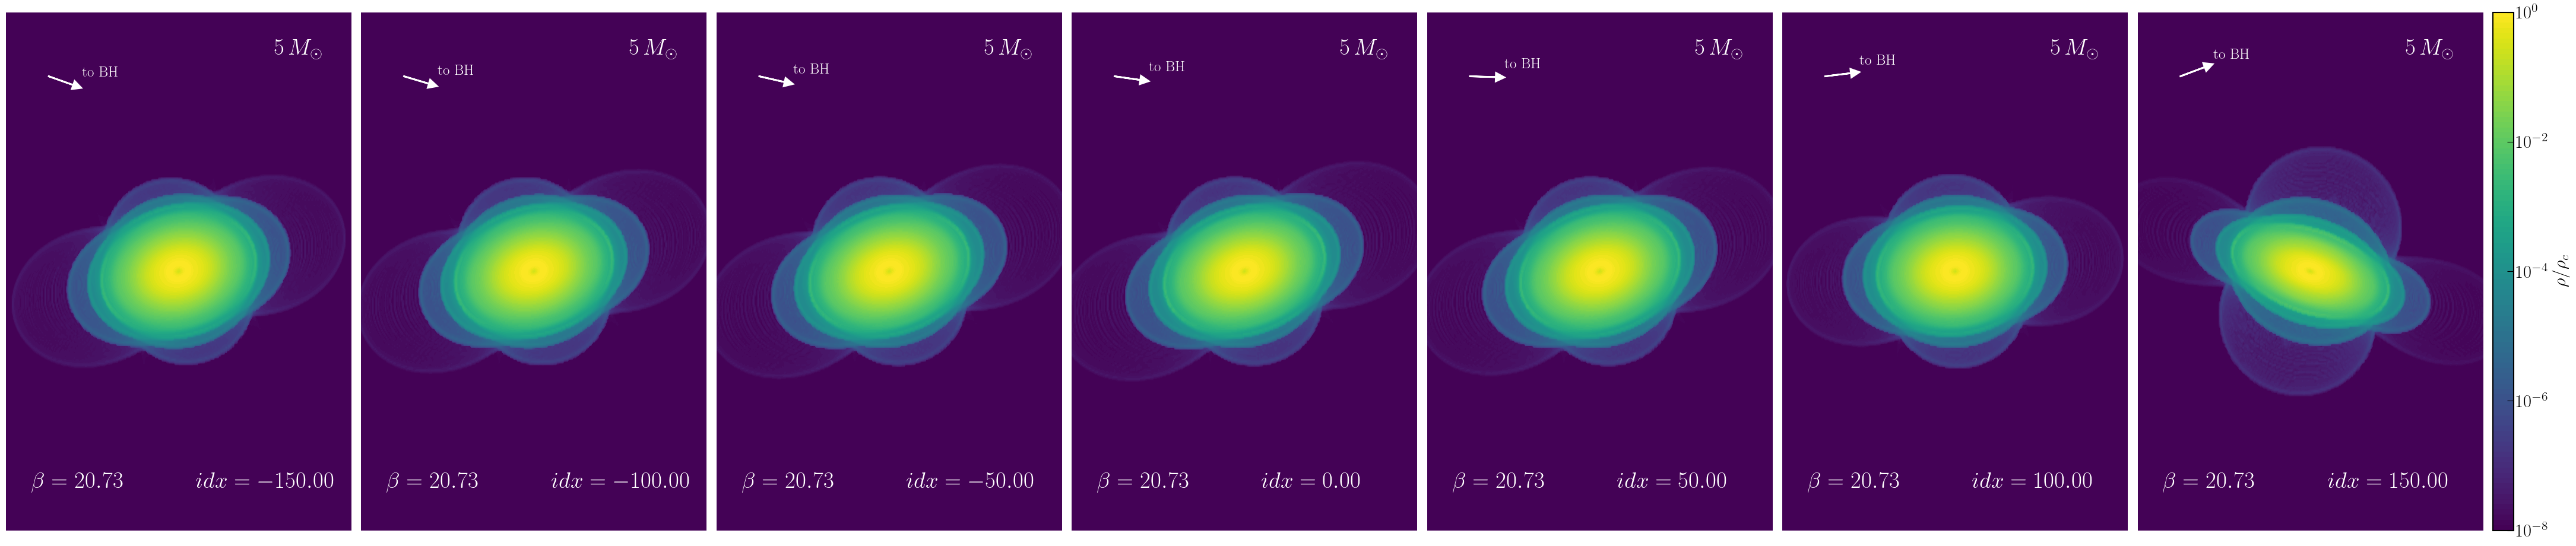

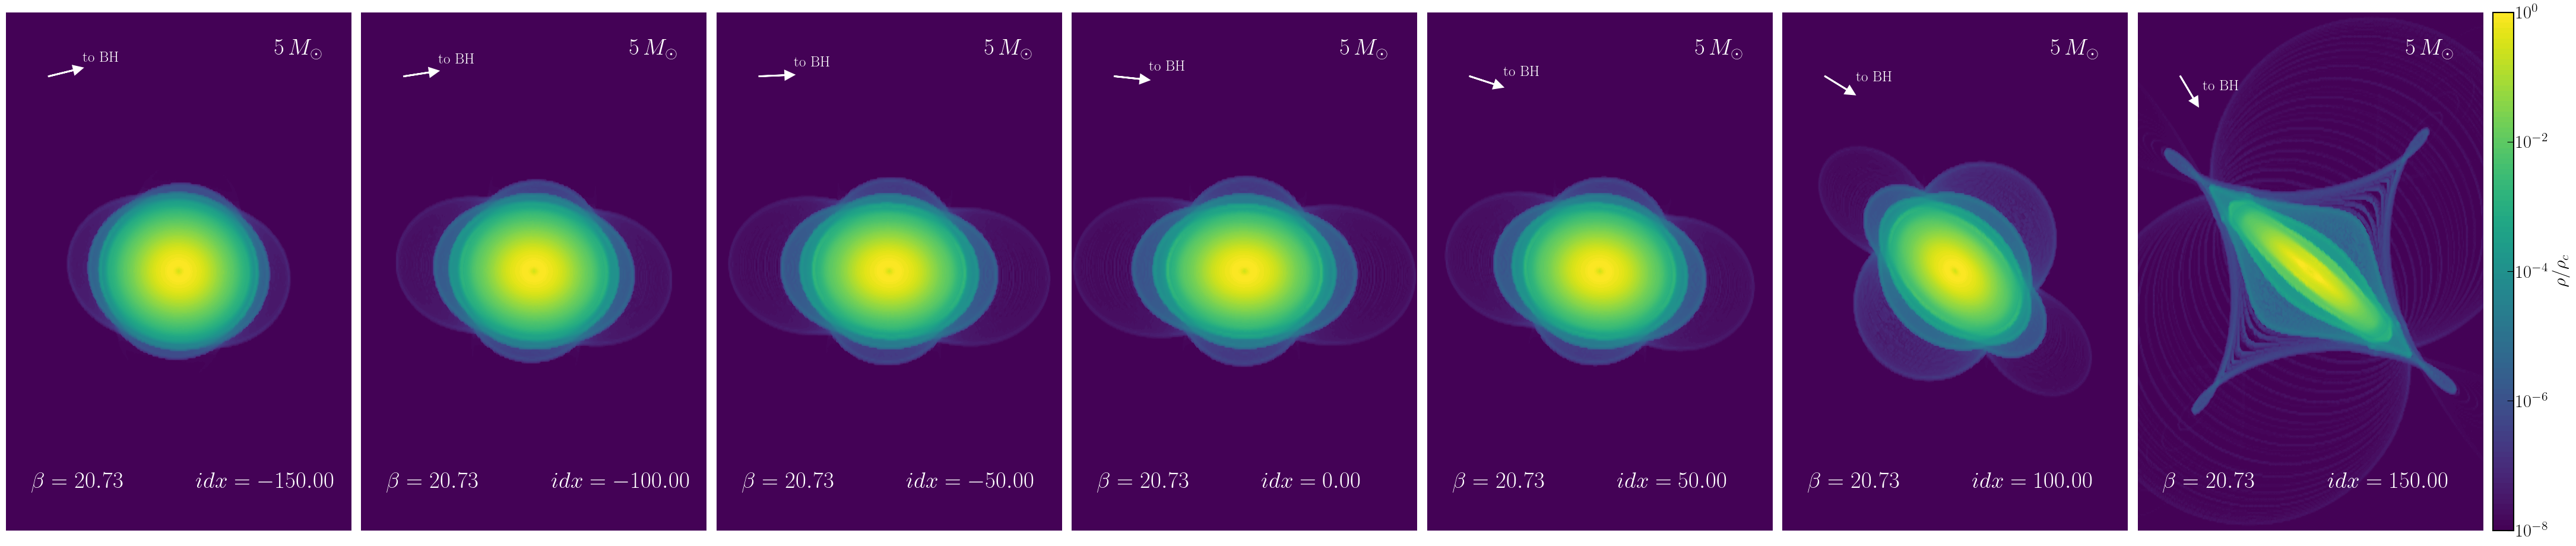

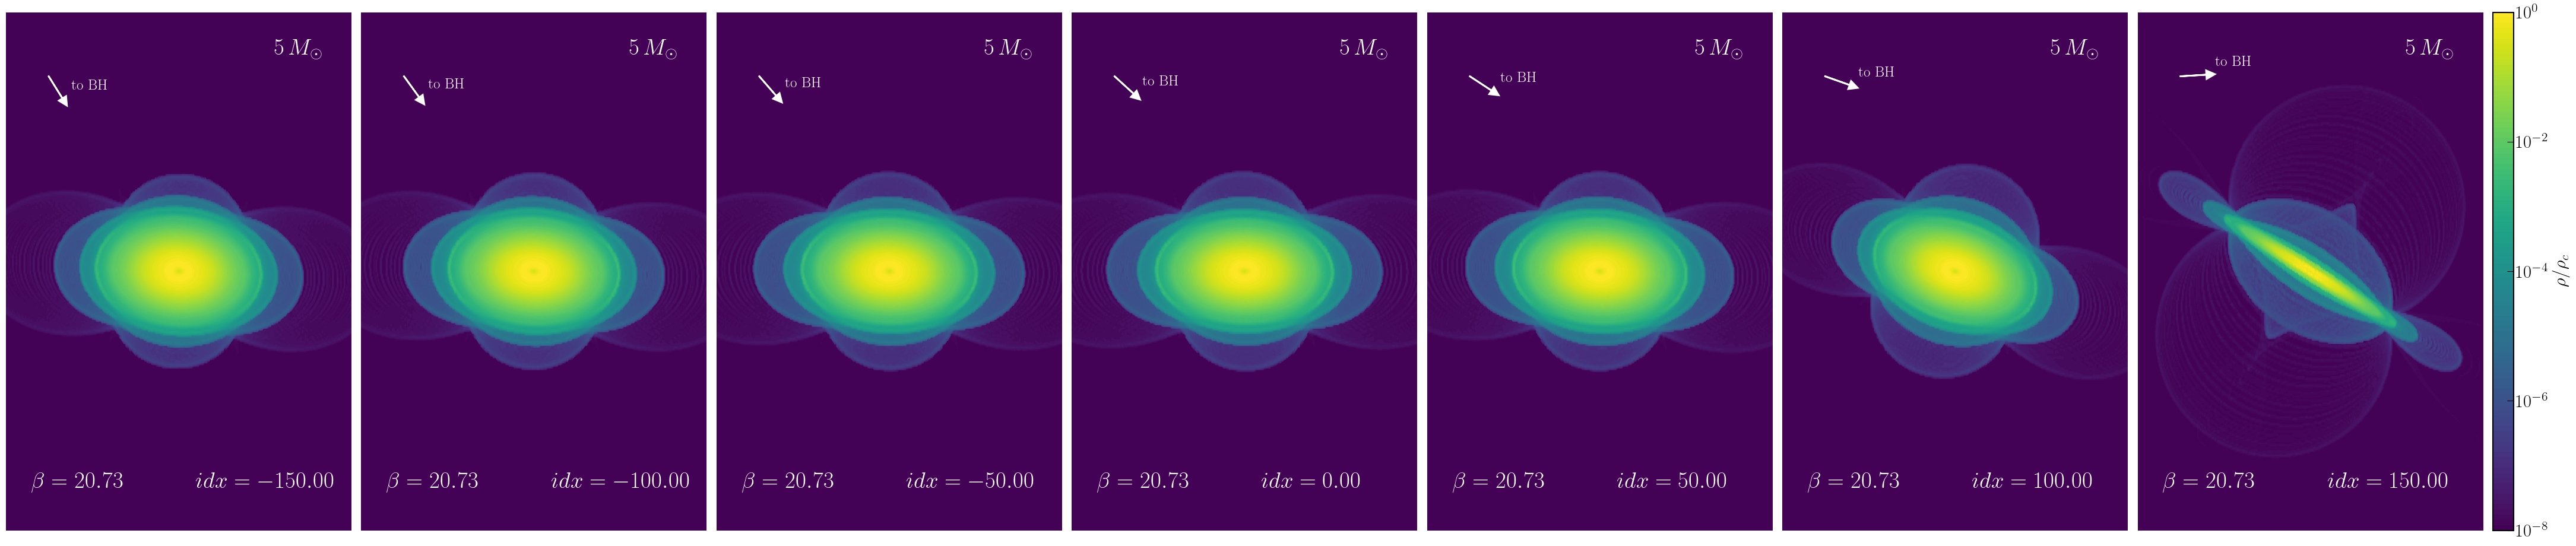

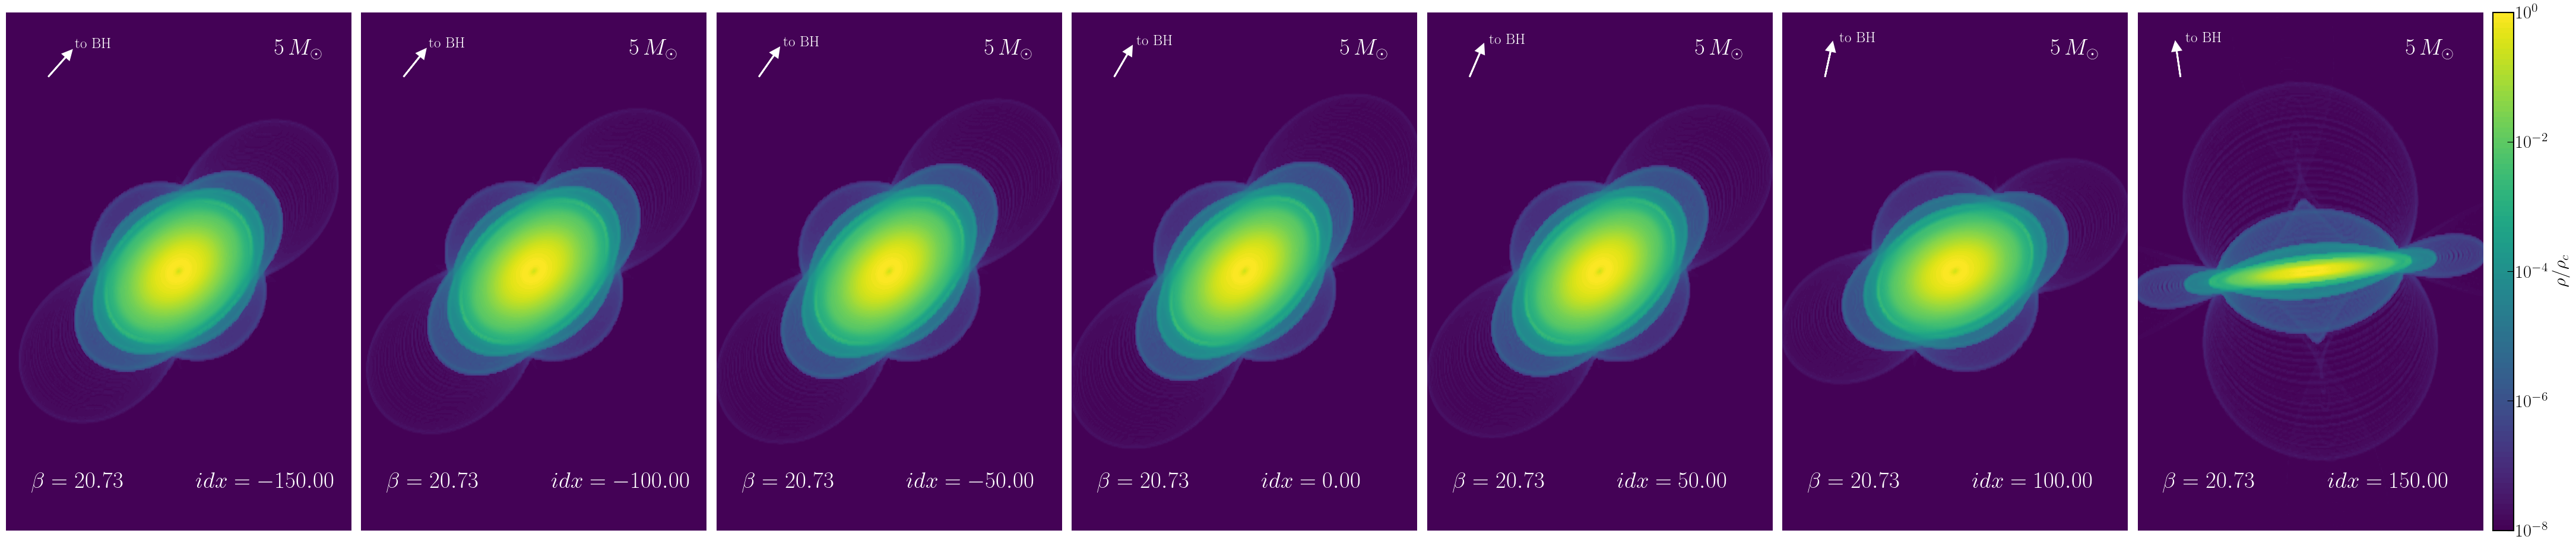

In [90]:
plot_dens_time(calc, times)
plot_dens_time(calc2, times)
plot_dens_time(calc_s, times)
plot_dens_time(calc_n, times)

In [117]:
def plotter(t, tau, r, phi, calc2, label):
    ttde = np.argmin(np.abs(calc2.t - calc2.t_TDE))

    if label == 'nwtn':
        x = r * np.cos(phi)
        y = r * np.sin(phi)

        tde = [ttde - 150, ttde - 100, ttde - 50, ttde, ttde + 50, ttde + 100, ttde + 150]
        rtde = r[tde]

        x_tde = rtde * np.cos(phi[tde])
        y_tde = rtde * np.sin(phi[tde])

    else:
        x = r(tau) * np.cos(phi(tau))
        y = r(tau) * np.sin(phi(tau))

        tde = calc2.t[[ttde - 150, ttde - 100, ttde - 50, ttde, ttde + 50, ttde + 100, ttde + 150]]
        rtde = r(tde)
        
        x_tde = rtde * np.cos(phi(tde))
        y_tde = rtde * np.sin(phi(tde))

    plt.figure(figsize=(6, 6))
    plt.plot(0, 0, 'ko', label='Black Hole')
    plt.gca().add_artist(plt.Circle((0, 0), 2, color='k', alpha=0.3))
    plt.plot(x, y, label=label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.axis("equal")
    plt.legend()
    plt.title("Parabolic Orbit")
    plt.plot(x_tde, y_tde, 'bo')
    plt.plot(x_tde[3], y_tde[3], 'go')
    plt.show()

In [118]:
tau = calc.t
t = calc.obs_t
r = calc.R
phi = calc.Phi

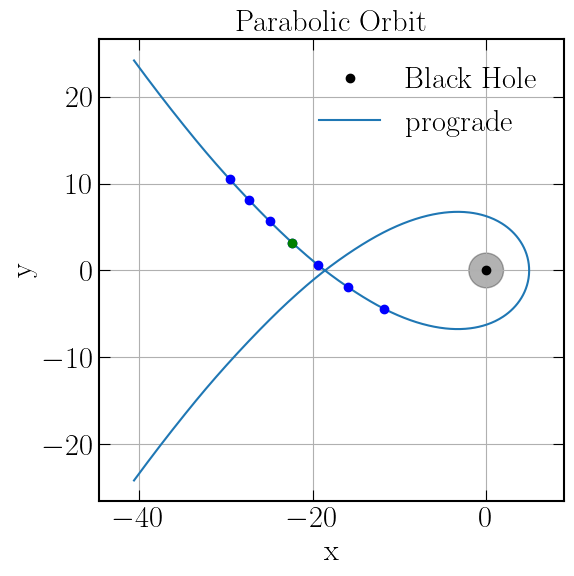

In [119]:
plotter(t, tau, r, phi, calc, "prograde")

In [120]:
tau2 = calc2.t
t2 = calc2.obs_t
r2 = calc2.R
phi2 = calc2.Phi

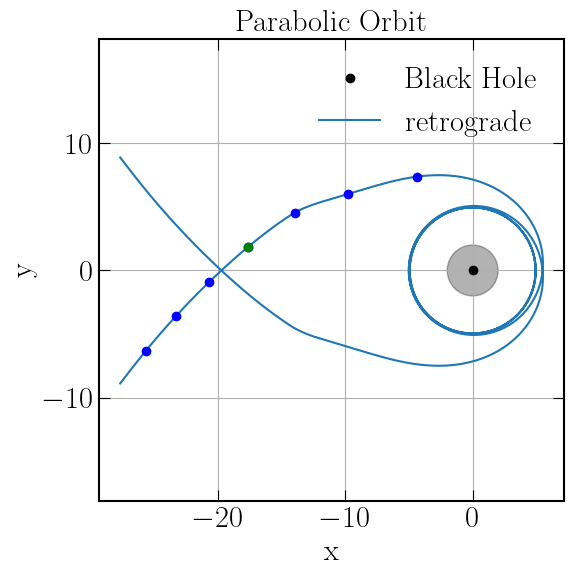

In [121]:
plotter(t2, tau2, r2, phi2, calc2, "retrograde")

In [122]:
taus = calc_s.t
ts = calc_s.obs_t
rs = calc_s.R
phis = calc_s.Phi

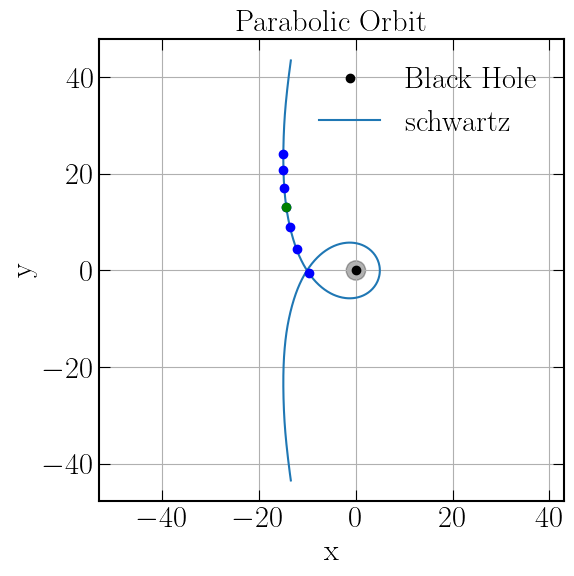

In [123]:
plotter(ts, taus, rs, phis, calc_s, "schwartz")

In [124]:
taun = calc_n.t
tn = calc_n.obs_t
rn = calc_n.R
phin = calc_n.Phi

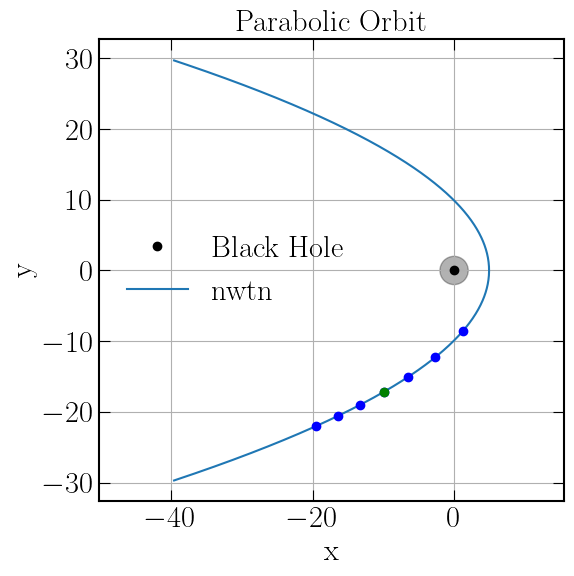

In [125]:
plotter(tn, taun, rn, phin, calc_n, "nwtn")